# Written text as operational data

Written text is one type of data

### Why people write?

 - To communicate: their thoughts, feelings, urgency, needs, information

### Why people communicate?

1. To express emotions
1. To share information
1. To enable or elicit an action
1. ...

### We will use written text for the purpose other than 
1. To experience emotion
1. To learn something the author intended us to learn
1. To do what the author intended us to do

### Instead, we will use written text to recognize who wrote it
 - By calculating and comparing word frequencies in written documents
 
See, for example, likely fictional story https://medium.com/@amuse/how-the-nsa-caught-satoshi-nakamoto-868affcef595

### Example 1. Dictionaries in python (associative arrays)

Plot the frequency distribution of words on a web page.

In [5]:
import requests, re
# re is a module for regular expressions: to detect various combinations of characters
import operator

# Start from a simple document
r = requests .get('http://eecs.utk.edu')

# What comes back includes headers and other HTTP stuff, get just the body of the response
t = r.text

# obtain words by splitting a string using as separator one or more (+) space/like characters (\s) 
wds = re.split('\s+',t)

# now populate a dictionary (wf)
wf = {}
for w in wds:
    if w in wf: wf [w] = wf [w] + 1
    else:  wf[w] = 1

# dictionaries can not be sorted, so lets get a sorted *list*        
wfs = sorted (wf .items(), key = operator .itemgetter (1), reverse=True)   

# lets just have no more than 15 words 
ml = min(len(wfs),15)
for i in range(1,ml,1):
    print (wfs[i][0]+"\t"+str(wfs[i][1]))  

class="menu-item	54
<div	54
menu-item-object-page	45
menu-item-type-post_type	45
of	39
</div>	38
<td	36
</td>	35
<li><a	35
class="eventless">	28
<link	25
<script	24
/>	21
</ul>	21


### Example 2

Lots of markup in the output, lets remove it --- 

use BeautifulSoup and nltk modules and practice some regular expressions.

In [12]:
import requests, re, nltk
from bs4 import BeautifulSoup
from nltk import clean_html
from collections import Counter
import operator

# we may not care about the usage of stop words
stop_words = nltk.corpus.stopwords.words('english') + [
 'ut', '\'re','.', ',', '--', '\'s', '?', ')', '(', ':', '\'',
 '\"', '-', '}', '{', '&', '|', u'\u2014' ]

# We most likely would like to remove html markup
def cleanHtml (html):
    from bs4 import BeautifulSoup
    soup = BeautifulSoup(html, 'html.parser')
    return soup .get_text()

# We also want to remove special characters, quotes, etc. from each word
def cleanWord (w):
    # r in r'[.,"\']' tells to treat \ as a regular character 
    # but we need to escape ' with \'
    # any character between the brackets [] is to be removed 
    wn = re.sub('[,"\.\'&\|:@>*;/=]', "", w)
    # get rid of numbers
    return re.sub('^[0-9\.]*$', "", wn)
       
# define a function to get text/clean/calculate frequency
def get_wf (URL):
    # first get the web page
    r = requests .get(URL)
    
    # Now clean
    # remove html markup
    t = cleanHtml (r .text) .lower()
    
    # split string into an array of words using any sequence of spaces "\s+" 
    wds = re .split('\s+',t)
    
    # remove periods, commas, etc stuck to the edges of words
    for i in range(len(wds)):
        wds [i] = cleanWord (wds [i])
    
    # If satisfied with results, lets go to the next step: calculate frequencies
    # We can write a loop to create a dictionary, but 
    # there is a special function for everything in python
    # in particular for counting frequencies (like function table() in R)
    wf = Counter (wds)
    
    # Remove stop words from the dictionary wf
    for k in stop_words:
        wf. pop(k, None)
        
    #how many regular words in the document?
    tw = 0
    for w in wf:
       tw += wf[w] 
        
    
    # Get ordered list
    wfs = sorted (wf .items(), key = operator.itemgetter(1), reverse=True)
    ml = min(len(wfs),15)

    #Reverse the list because barh plots items from the bottom
    return (wfs [ 0:ml ] [::-1], tw)
        
# Now populate two lists    
(wf_ee, tw_ee) = get_wf('http://www.gutenberg.org/ebooks/1342.txt.utf-8')
(wf_bu, tw_bu) = get_wf('http://www.gutenberg.org/ebooks/76.txt.utf-8')

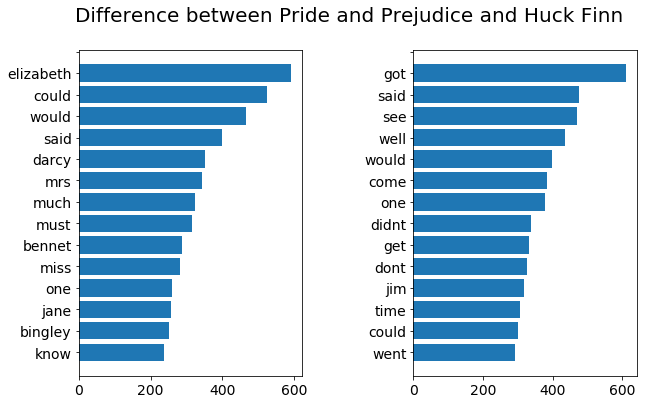

In [14]:
#Plot the results: are there striking differences in language?
import numpy as np
import pylab
import matplotlib.pyplot as plt

%matplotlib inline
def plotTwoLists (wf_ee, wf_bu, title):
    f = plt.figure (figsize=(10, 6))
    # this is painfully tedious....
    f .suptitle (title, fontsize=20)
    ax = f.add_subplot(111)
    ax .spines ['top'] .set_color ('none')
    ax .spines ['bottom'] .set_color ('none')
    ax .spines ['left'] .set_color ('none')
    ax .spines ['right'] .set_color ('none')
    ax .tick_params (labelcolor='w', top='off', bottom='off', left='off', right='off', labelsize=20)

    # Create two subplots, this is the first one
    ax1 = f .add_subplot (121)
    plt .subplots_adjust (wspace=.5)

    pos = np .arange (len(wf_ee)+1) 
    ax1 .tick_params (axis='both', which='major', labelsize=14)
    pylab .yticks (pos, [ x [0] for x in wf_ee ])
    ax1 .barh (range(len(wf_ee)), [ x [1] for x in wf_ee ], align='center')

    ax2 = f .add_subplot (122)
    ax2 .tick_params (axis='both', which='major', labelsize=14)
    pos = np .arange (len(wf_bu)+1) 
    pylab .yticks (pos, [ x [0] for x in wf_bu ])
    ax2 .barh (range (len(wf_bu)), [ x [1] for x in wf_bu ], align='center')

plotTwoLists (wf_ee, wf_bu, 'Difference between Pride and Prejudice and Huck Finn')

In [9]:
#In case Project gutenberg is blocked you can download text to your laptop and copy to the docker container via scp
#Assuming the file name you copy is pg4680.txt here is how you change the script
# Please note the option errors='replace'
# without it python invariably runs into unicode errors
f = open ('pg4680.txt', 'r', encoding="ascii", errors='replace')
    
# What comes back includes headers and other HTTP stuff, get just the body of the response
t = f.read()

# obtain words by splitting a string using as separator one or more (+) space/like characters (\s) 
wds = re.split('\s+',t)

# now populate a dictionary (wf)
wf = {}
for w in wds:
    if w in wf: wf [w] = wf [w] + 1
    else:  wf [w] = 1

# dictionaries can not be sorted, so lets get a sorted *list*        
wfs = sorted (wf .items(), key = operator .itemgetter (1), reverse=True)   

# lets just have no more than 15 words 
ml = min(len(wfs),15)
for i in range(1,ml,1):
    print (wfs[i][0]+"\t"+str(wfs[i][1]))  

and	2836
of	2676
to	2646
a	2217
in	1422
his	1205
he	928
that	920
was	823
for	798
with	797
as	672
I	505
you	497


# Assignment 1

1. Compare word frequencies between two works of a single author.
1. Compare word frequencies between works of two authors.
1. Are there some words preferred by one author but used less frequently by another author?

Extra credit

1. The frequency of a specific word, e.g., "would" should follow a binomial distribution (each regular word in a document is a trial and with probability p that word is "would". The estimate for p is N("would")/N(regular word)). Do these binomial distributions for your chosen word differ significantly between books of the same author or between authors? 

Project Gutenberg is a good source of for fiction and non-fiction.

E.g below are two most popular books from Project Gutenberg:
- Pride and Prejudice at http://www.gutenberg.org/ebooks/1342.txt.utf-8
- Adventures of Huckleberry Finn at http://www.gutenberg.org/ebooks/76.txt.utf-8

In [2]:
import re
import math
import requests
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
urls = {
    "Pride and Prejudice": "https://www.gutenberg.org/files/1342/1342-0.txt",
    "Emma": "https://www.gutenberg.org/files/158/158-0.txt",
    "Huckleberry Finn": "https://www.gutenberg.org/files/76/76-0.txt"
}

In [4]:
texts = {}

for title, url in urls.items():
    response = requests.get(url)
    texts[title] = response.text
    print(title, len(response.text))

Pride and Prejudice 728846
Emma 880527
Huckleberry Finn 571153


In [5]:
def get_words(text):
    return re.findall(r"[a-z]+", text.lower())

words = {}

for title, text in texts.items():
    words[title] = get_words(text)
    print(title, len(words[title]))

Pride and Prejudice 128577
Emma 162111
Huckleberry Finn 117789


In [6]:
counts = {}

for title in words:
    counts[title] = Counter(words[title])

In [7]:
counts["Pride and Prejudice"].most_common(20)

[('the', 4665),
 ('to', 4325),
 ('of', 3846),
 ('and', 3767),
 ('her', 2284),
 ('i', 2122),
 ('a', 2038),
 ('in', 1994),
 ('was', 1875),
 ('she', 1751),
 ('that', 1646),
 ('it', 1590),
 ('not', 1500),
 ('you', 1376),
 ('he', 1358),
 ('his', 1303),
 ('be', 1264),
 ('as', 1229),
 ('had', 1186),
 ('with', 1103)]

In [8]:
def frequency_per_10000(title, word):
    return counts[title][word] / len(words[title]) * 10000

In [9]:
print(frequency_per_10000("Pride and Prejudice", "love"))
print(frequency_per_10000("Emma", "love"))

7.932989570451947
7.217277050909562


In [10]:
compare_words = [
    "love",
    "marriage",
    "happy",
    "friend",
    "family",
    "feel",
    "think",
    "know"
]

data = []

for word in compare_words:
    data.append({
        "word": word,
        "Pride and Prejudice": frequency_per_10000(
            "Pride and Prejudice", word
        ),
        "Emma": frequency_per_10000(
            "Emma", word
        )
    })

same_author = pd.DataFrame(data)

same_author

,word,Pride and Prejudice,Emma
0,love,7.932990,7.217277
1,marriage,5.210885,2.159015
2,happy,6.455276,7.710766
3,friend,8.944057,10.918445
4,family,11.899484,4.749832
5,feel,3.188751,5.860182
6,think,17.265918,23.687473
7,know,18.976955,20.788225


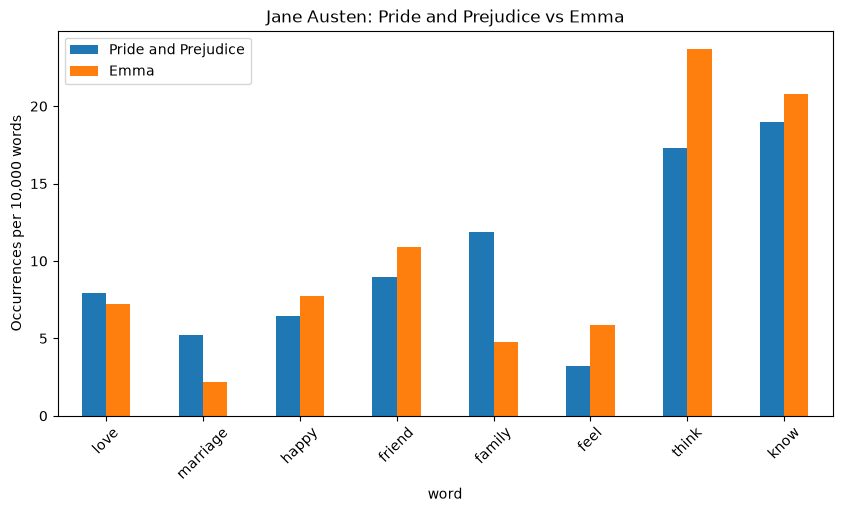

In [11]:
same_author.set_index("word").plot(kind="bar", figsize=(10, 5))

plt.ylabel("Occurrences per 10,000 words")
plt.title("Jane Austen: Pride and Prejudice vs Emma")
plt.xticks(rotation=45)
plt.show()

Result: Pride and Prejudice and Emma show some similar word-use patterns, but several words differ noticeably even though both books were written by Jane Austen. For example, "marriage" and "family" occur more frequently in Pride and Prejudice, while "think" and "friend" occur more frequently in Emma. This suggests that word usage varies somewhat within an author's works depending on the subject matter of the novel.

In [12]:
data = []

for word in compare_words:
    data.append({
        "word": word,
        "Austen": frequency_per_10000(
            "Pride and Prejudice", word
        ),
        "Twain": frequency_per_10000(
            "Huckleberry Finn", word
        )
    })

different_authors = pd.DataFrame(data)

different_authors

,word,Austen,Twain
0,love,7.932990,0.764078
1,marriage,5.210885,0.000000
2,happy,6.455276,0.679181
3,friend,8.944057,1.697951
4,family,11.899484,2.886517
5,feel,3.188751,3.735493
6,think,17.265918,11.970558
7,know,18.976955,21.903573


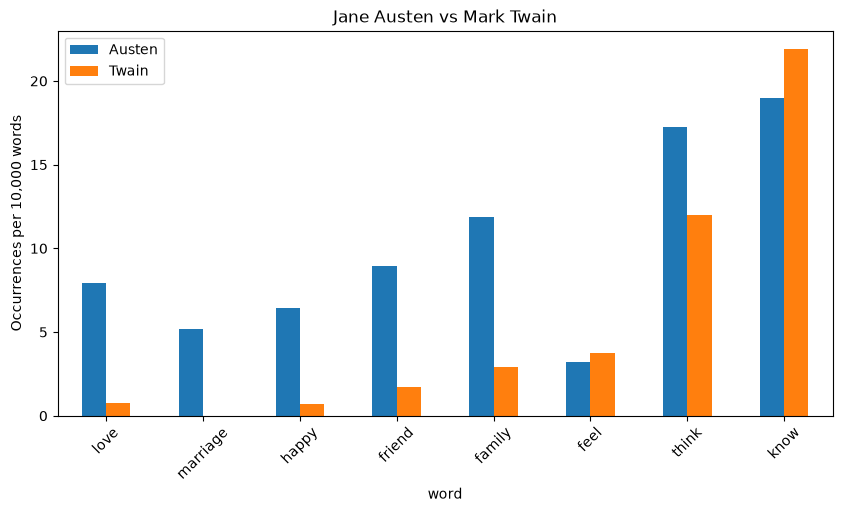

In [13]:
different_authors.set_index("word").plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Occurrences per 10,000 words")
plt.title("Jane Austen vs Mark Twain")
plt.xticks(rotation=45)
plt.show()

Result: The differences between Austen and Twain are generally larger. Words such as "love," "marriage," and "family" occur much more frequently in Pride and Prejudice, while Twain uses more conversational language. This suggests that vocabulary frequency can capture differences in both subject matter and authorial style.

In [14]:
all_words = set(counts["Pride and Prejudice"]) | set(
    counts["Huckleberry Finn"]
)

results = []

for word in all_words:
    if len(word) < 4:
        continue

    austen_count = counts["Pride and Prejudice"][word]
    twain_count = counts["Huckleberry Finn"][word]

    if austen_count + twain_count < 20:
        continue

    austen_freq = frequency_per_10000(
        "Pride and Prejudice", word
    )

    twain_freq = frequency_per_10000(
        "Huckleberry Finn", word
    )

    results.append({
        "word": word,
        "Austen": austen_freq,
        "Twain": twain_freq,
        "difference": austen_freq - twain_freq
    })

preferred = pd.DataFrame(results)

In [15]:
preferred.sort_values(
    "difference",
    ascending=False
).head(15)

,word,Austen,Twain,difference
671,have,68.363704,15.281563,53.082141
34,elizabeth,50.164493,0.000000,50.164493
733,were,44.331412,0.764078,43.567334
798,with,85.785172,45.589996,40.195176
415,which,44.175863,9.848118,34.327745
371,darcy,33.598544,0.000000,33.598544
660,very,39.198301,8.489757,30.708544
789,been,41.687082,11.546070,30.141013
238,will,33.287446,5.263649,28.023797
899,bennet,26.365524,0.000000,26.365524


In [16]:
preferred.sort_values(
    "difference"
).head(15)

,word,Austen,Twain,difference
922,says,1.166616,54.164650,-52.998034
413,then,13.766070,50.938543,-37.172473
766,down,6.144178,41.175322,-35.031144
519,didn,0.000000,30.648023,-30.648023
670,come,7.621892,33.874131,-26.252239
87,there,28.932080,55.013626,-26.081546
824,about,10.032899,35.741877,-25.708979
294,warn,0.311098,25.214579,-24.903481
926,they,47.442389,71.908243,-24.465854
362,right,3.499848,25.808862,-22.309013


Result: Yes, some words appear to be preferred by one author. After normalizing by total book length, several words have substantially different frequencies between Austen and Twain. However, character names and plot-specific vocabulary should not be interpreted as stylistic preferences, which is why filtering stop words and names improves the comparison.